# Stage 1 sweep analysis

Reusable analysis notebook for Stage 1 sweeps. Set `FEATURE_MODE` to `koppen`, `raw`, or `pca` and rerun the notebook.

This notebook reports:

- top 5 configurations by lowest mean fitness,
- top 5 configurations by mean weighted ecological consistency,
- mean fitness and ecological consistency by algorithm and by parameter value,
- distributions of fitness and ecological consistency overall, by algorithm, and by parameter value,
- optional exports of the main analysis tables.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

FEATURE_MODE = "raw"  # "koppen", "raw", or "pca"
RESULTS_ROOT = Path("../experiments/results")
BASE_DIR = RESULTS_ROOT / FEATURE_MODE
SUMMARY_PATH = BASE_DIR / "stage1_sweep_summary.csv"
RUNS_PATH = BASE_DIR / "stage1_sweep_runs.csv"
OUTPUT_DIR = BASE_DIR / "analysis_outputs"

TOP_N = 5
N_BINS = 20

FITNESS_COL = "mean_best_fitness"
ECO_COL = "mean_weighted_combined_ecological_consistency"
ARI_COL = "mean_ari_vs_kmeans"

RUN_FITNESS_COL = "best_fitness"
RUN_ECO_COL = "weighted_combined_ecological_consistency"
RUN_ARI_COL = "ari_vs_kmeans"

PARAM_COLS = ["algorithm", "pheromone_update", "alpha", "beta", "evaporation", "q"]
CONFIG_COLS = ["algorithm", "pheromone_update", "alpha", "beta", "evaporation", "q", "feature_mode", "mode"]

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
plt.style.use("default")

## 1. Load data

In [6]:
def read_csv_auto(path):
    if not path.exists():
        raise FileNotFoundError(path)
    try:
        df = pd.read_csv(path, sep=";")
        if df.shape[1] > 1:
            return df
    except pd.errors.ParserError:
        pass
    return pd.read_csv(path)

summary = read_csv_auto(SUMMARY_PATH)
runs = read_csv_auto(RUNS_PATH)

print("Feature mode:", FEATURE_MODE)
print("Summary path:", SUMMARY_PATH)
print("Runs path:", RUNS_PATH)
print("Summary rows:", len(summary), "columns:", len(summary.columns))
print("Run rows:", len(runs), "columns:", len(runs.columns))
display(summary.head())

Feature mode: raw
Summary path: ../experiments/results/raw/stage1_sweep_summary.csv
Runs path: ../experiments/results/raw/stage1_sweep_runs.csv
Summary rows: 252 columns: 33
Run rows: 504 columns: 36


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_compactness,std_compactness,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec
0,aco_centroid,all_ants,1.00,1.0,0.10,0.05,raw,superpixels,0.261068,0.012981,0.251889,0.261068,0.012981,0.251889,0.230373,0.011926,0.332690,0.015443,0.651449,0.187204,0.483142,0.006551,0.487774,0.477867,0.002528,0.409770,0.007287,0.489578,0.001801,0.037958,0.000043,28.527558,0.222895
1,aco_centroid,all_ants,1.00,1.0,0.02,0.05,raw,superpixels,0.258811,0.003487,0.256345,0.258811,0.003487,0.256345,0.228168,0.003992,0.330310,0.002310,0.660394,0.119485,0.480203,0.004826,0.483615,0.474415,0.003327,0.403436,0.002789,0.488633,0.001394,0.037949,0.000030,28.554608,0.038818
2,aco_centroid_refinement,all_ants,0.75,1.0,0.02,0.05,raw,superpixels,0.284579,0.010057,0.277468,0.284579,0.010057,0.277468,0.245760,0.002960,0.375156,0.026618,0.651705,0.040614,0.480121,0.000218,0.480275,0.471562,0.002713,0.411954,0.002440,0.487987,0.003164,0.037944,0.000048,72.337820,0.893228
3,aco_centroid_refinement,all_ants,1.00,1.0,0.10,0.05,raw,superpixels,0.281243,0.003529,0.278748,0.281243,0.003529,0.278748,0.247895,0.004735,0.359056,0.022812,0.613175,0.037560,0.479933,0.003399,0.482336,0.476158,0.003312,0.410215,0.006592,0.487000,0.000809,0.037962,0.000037,70.130282,0.536506
4,aco_centroid_refinement,all_ants,1.00,1.0,0.02,0.05,raw,superpixels,0.276150,0.001216,0.275291,0.276150,0.001216,0.275291,0.245619,0.008417,0.347390,0.023692,0.624824,0.033712,0.479550,0.003793,0.482232,0.478367,0.001896,0.407418,0.007760,0.487699,0.002833,0.037934,0.000048,69.861212,0.032186


## 2. Basic checks

In [7]:
required_summary_cols = CONFIG_COLS + [FITNESS_COL, ECO_COL, ARI_COL]
required_run_cols = CONFIG_COLS + ["seed", RUN_FITNESS_COL, RUN_ECO_COL, RUN_ARI_COL]

missing_summary = [c for c in required_summary_cols if c not in summary.columns]
missing_runs = [c for c in required_run_cols if c not in runs.columns]
if missing_summary:
    raise ValueError(f"Missing summary columns: {missing_summary}")
if missing_runs:
    raise ValueError(f"Missing run columns: {missing_runs}")

summary = summary.dropna(subset=[FITNESS_COL, ECO_COL]).copy()
runs = runs.dropna(subset=[RUN_FITNESS_COL, RUN_ECO_COL]).copy()

for df in [summary, runs]:
    for col in ["alpha", "beta", "evaporation", "q"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Feature modes in summary:", sorted(summary["feature_mode"].unique()))
print("Algorithms:", sorted(summary["algorithm"].unique()))
print("Pheromone updates:", sorted(summary["pheromone_update"].unique()))
print("Seeds in runs:", sorted(runs["seed"].unique()))

Feature modes in summary: ['raw']
Algorithms: ['aco_centroid', 'aco_centroid_refinement', 'aco_cohesion', 'aco_cohesion_refinement', 'aco_graph_local', 'multi_centroid_graph_spatial', 'multi_cohesion_graph_spatial']
Pheromone updates: ['all_ants', 'best_ant', 'quality_weighted']
Seeds in runs: [0, 1]


## 3. Helper functions

In [8]:
def metric_direction(col):
    if "fitness" in col:
        return "lower_is_better"
    if "ecological" in col or "eco" in col:
        return "higher_is_better"
    return "unspecified"


def describe_metric(data, col):
    s = data[col]
    direction = metric_direction(col)
    min_value = s.min()
    max_value = s.max()
    return pd.Series({
        "direction": direction,
        "count": s.count(),
        "mean": s.mean(),
        "std": s.std(),
        "worst": max_value if direction == "lower_is_better" else min_value,
        "p25": s.quantile(0.25),
        "median": s.median(),
        "p75": s.quantile(0.75),
        "best": min_value if direction == "lower_is_better" else max_value,
        "min": min_value,
        "max": max_value,
        "range": max_value - min_value,
    })


def distribution_table(data, metric_cols):
    return pd.DataFrame([describe_metric(data, c).rename(c) for c in metric_cols]).reset_index().rename(columns={"index": "metric"})


def grouped_distribution(data, group_col, metric_cols):
    rows = []
    for value, subset in data.groupby(group_col, dropna=False):
        dist = distribution_table(subset, metric_cols)
        dist.insert(0, "value", value)
        dist.insert(0, "group", group_col)
        rows.append(dist)
    return pd.concat(rows, ignore_index=True)


def mean_by_group(data, group_col):
    return (
        data.groupby(group_col, dropna=False)
        .agg(
            configs=(group_col, "size"),
            mean_fitness=(FITNESS_COL, "mean"),
            std_fitness=(FITNESS_COL, "std"),
            mean_eco=(ECO_COL, "mean"),
            std_eco=(ECO_COL, "std"),
            min_fitness=(FITNESS_COL, "min"),
            max_eco=(ECO_COL, "max"),
        )
        .reset_index()
        .sort_values("mean_fitness", ascending=True)
    )


def plot_hist(data, col, title, bins=N_BINS):
    ax = data[col].hist(bins=bins, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    plt.show()


def plot_box_by_group(data, col, group_col, title):
    order = sorted(data[group_col].dropna().unique())
    ax = data.boxplot(column=col, by=group_col, rot=45, grid=False, figsize=(10, 4))
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(col)
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 4. Top 5 configurations

In [9]:
display_cols = CONFIG_COLS + [
    FITNESS_COL,
    "std_best_fitness",
    "best_best_fitness",
    ECO_COL,
    "std_weighted_combined_ecological_consistency",
    "best_weighted_combined_ecological_consistency",
    ARI_COL,
    "mean_compactness",
    "mean_spatial",
]
display_cols = [c for c in display_cols if c in summary.columns]

top_by_fitness = summary.sort_values([FITNESS_COL, ECO_COL], ascending=[True, False]).head(TOP_N)[display_cols]
top_by_ecology = summary.sort_values([ECO_COL, FITNESS_COL], ascending=[False, True]).head(TOP_N)[display_cols]

print(f"Top {TOP_N} by lowest mean fitness")
display(top_by_fitness)

print(f"Top {TOP_N} by mean weighted ecological consistency")
display(top_by_ecology)

Top 5 by lowest mean fitness


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_ari_vs_kmeans,mean_compactness,mean_spatial
23,aco_centroid,best_ant,1.00,3.0,0.10,0.05,raw,superpixels,0.233212,0.011422,0.225135,0.470411,0.008112,0.476147,0.731769,0.217170,0.270641
61,aco_centroid,best_ant,0.75,3.0,0.10,0.05,raw,superpixels,0.233234,0.000716,0.232727,0.461955,0.001520,0.463030,0.578111,0.227588,0.246407
15,aco_centroid,best_ant,1.00,3.0,0.02,0.05,raw,superpixels,0.236260,0.009954,0.229222,0.471266,0.010691,0.478826,0.701195,0.219432,0.275526
58,aco_centroid,best_ant,0.75,3.0,0.02,0.05,raw,superpixels,0.237804,0.005854,0.233664,0.462491,0.000724,0.463003,0.581061,0.228284,0.260017
22,aco_centroid_refinement,all_ants,0.75,3.0,0.10,0.05,raw,superpixels,0.238115,0.002193,0.236564,0.470579,0.001369,0.471547,0.783195,0.215282,0.291392


Top 5 by mean weighted ecological consistency


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_ari_vs_kmeans,mean_compactness,mean_spatial
0,aco_centroid,all_ants,1.00,1.0,0.10,0.05,raw,superpixels,0.261068,0.012981,0.251889,0.483142,0.006551,0.487774,0.651449,0.230373,0.332690
1,aco_centroid,all_ants,1.00,1.0,0.02,0.05,raw,superpixels,0.258811,0.003487,0.256345,0.480203,0.004826,0.483615,0.660394,0.228168,0.330310
2,aco_centroid_refinement,all_ants,0.75,1.0,0.02,0.05,raw,superpixels,0.284579,0.010057,0.277468,0.480121,0.000218,0.480275,0.651705,0.245760,0.375156
3,aco_centroid_refinement,all_ants,1.00,1.0,0.10,0.05,raw,superpixels,0.281243,0.003529,0.278748,0.479933,0.003399,0.482336,0.613175,0.247895,0.359056
4,aco_centroid_refinement,all_ants,1.00,1.0,0.02,0.05,raw,superpixels,0.276150,0.001216,0.275291,0.479550,0.003793,0.482232,0.624824,0.245619,0.347390


## 5. Mean fitness and ecology by algorithm and parameters

In [13]:
parameter_means = []
for param in PARAM_COLS:
    print(f"By {param}")
    table = mean_by_group(summary, param).rename(columns={param: "value"})
    # table.insert(0, "parameter", param)
    parameter_means.append(table)
    display(table)
parameter_means = pd.concat(parameter_means, ignore_index=True)

# display(parameter_means)

By algorithm


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
0,aco_centroid,36,0.283130,0.050769,0.467052,0.007292,0.233212,0.483142
1,aco_centroid_refinement,36,0.335388,0.120998,0.461831,0.015091,0.238115,0.480121
5,multi_centroid_graph_spatial,36,0.367179,0.100372,0.452830,0.009715,0.264130,0.465115
4,aco_graph_local,36,0.589290,0.181901,0.429359,0.015515,0.360547,0.450651
6,multi_cohesion_graph_spatial,36,0.589949,0.230238,0.426713,0.019973,0.268278,0.457843
3,aco_cohesion_refinement,36,0.603403,0.296676,0.427724,0.030327,0.244212,0.465337
2,aco_cohesion,36,0.621993,0.278732,0.423563,0.026596,0.249371,0.459983


By pheromone_update


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
0,all_ants,84,0.465003,0.242835,0.443397,0.027064,0.238115,0.483142
2,quality_weighted,84,0.487461,0.239389,0.440502,0.024864,0.239552,0.473986
1,best_ant,84,0.500535,0.240587,0.439989,0.025598,0.233212,0.473710


By alpha


...

,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
1,3.0,126,0.318079,0.072001,0.456308,0.011134,0.233212,0.478792
0,1.0,126,0.650587,0.234878,0.426284,0.027535,0.250278,0.483142


By evaporation


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
1,0.10,126,0.483070,0.241028,0.441421,0.025887,0.233212,0.483142
0,0.02,126,0.485596,0.240784,0.441172,0.025813,0.236260,0.480203


By q


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
0,0.05,252,0.484333,0.240429,0.441296,0.025799,0.233212,0.483142


## 6. Overall distributions

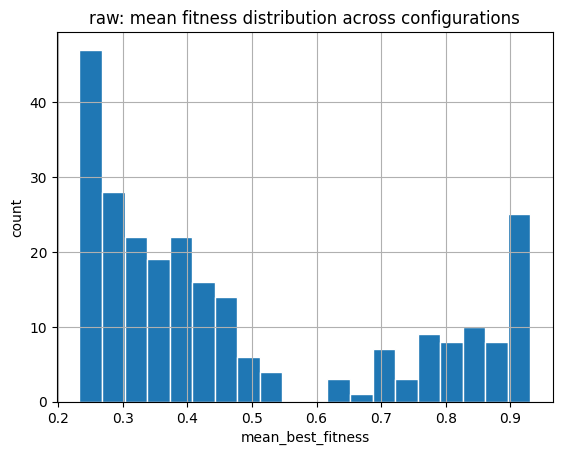

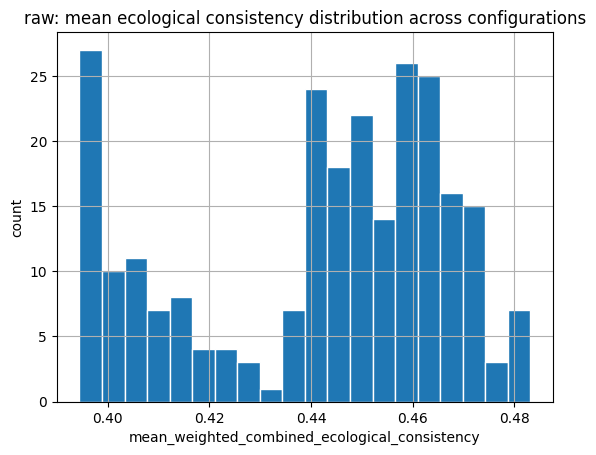

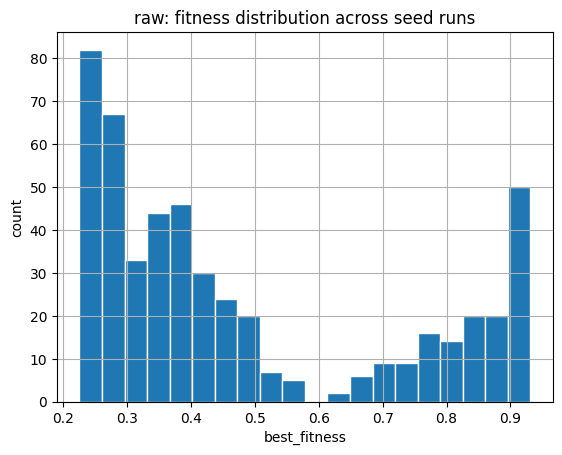

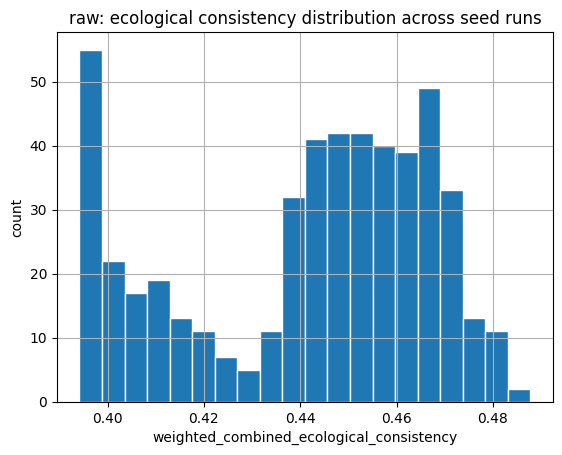

In [15]:
plot_hist(summary, FITNESS_COL, f"{FEATURE_MODE}: mean fitness distribution across configurations")
plot_hist(summary, ECO_COL, f"{FEATURE_MODE}: mean ecological consistency distribution across configurations")
plot_hist(runs, RUN_FITNESS_COL, f"{FEATURE_MODE}: fitness distribution across seed runs")
plot_hist(runs, RUN_ECO_COL, f"{FEATURE_MODE}: ecological consistency distribution across seed runs")

## 7. Distributions by algorithm

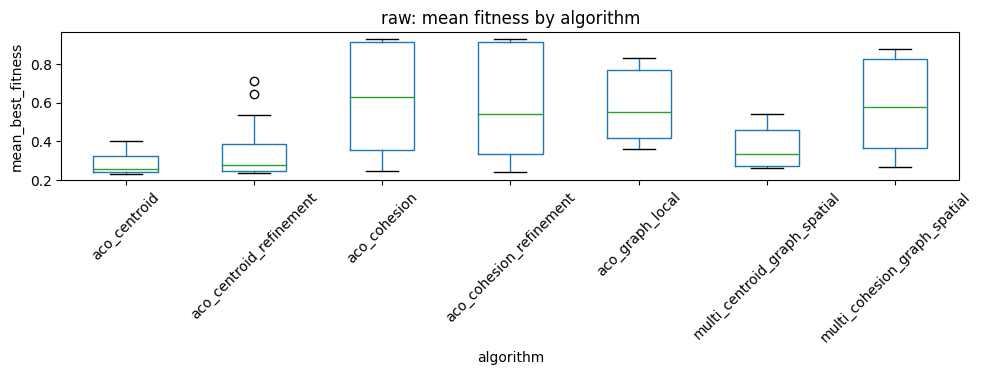

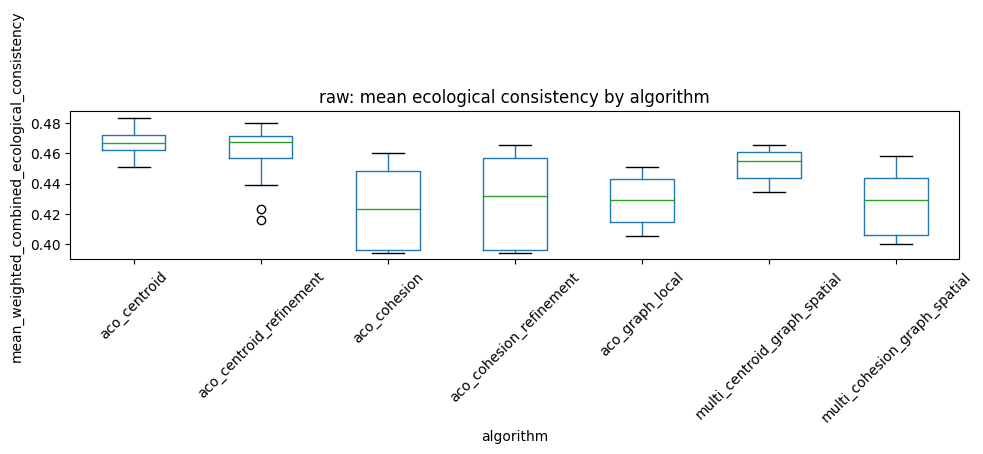

In [17]:
plot_box_by_group(summary, FITNESS_COL, "algorithm", f"{FEATURE_MODE}: mean fitness by algorithm")
plot_box_by_group(summary, ECO_COL, "algorithm", f"{FEATURE_MODE}: mean ecological consistency by algorithm")

## 8. Distributions by parameter value

===== pheromone_update =====


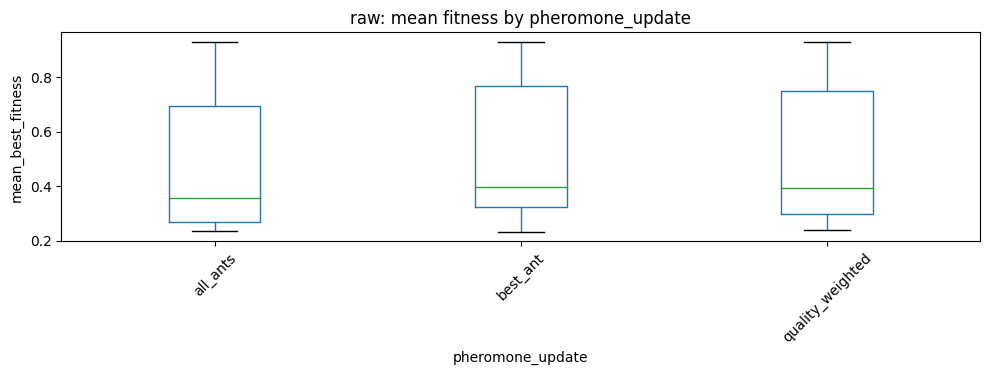

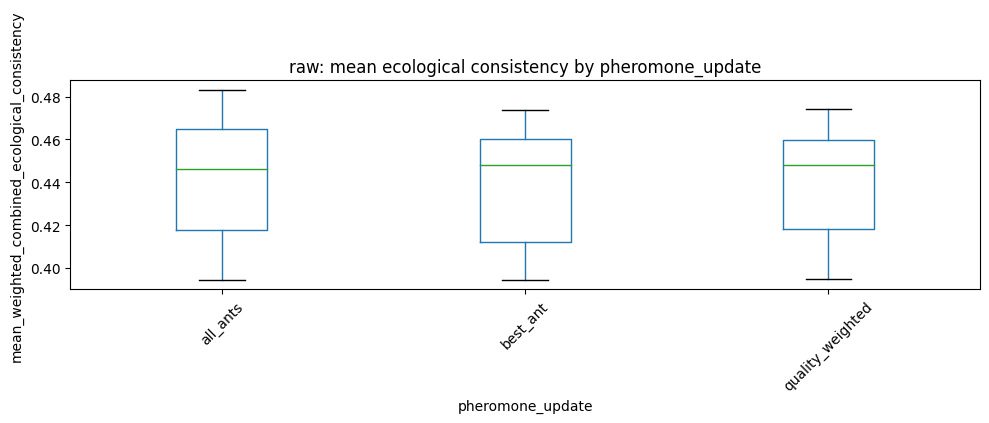

===== alpha =====


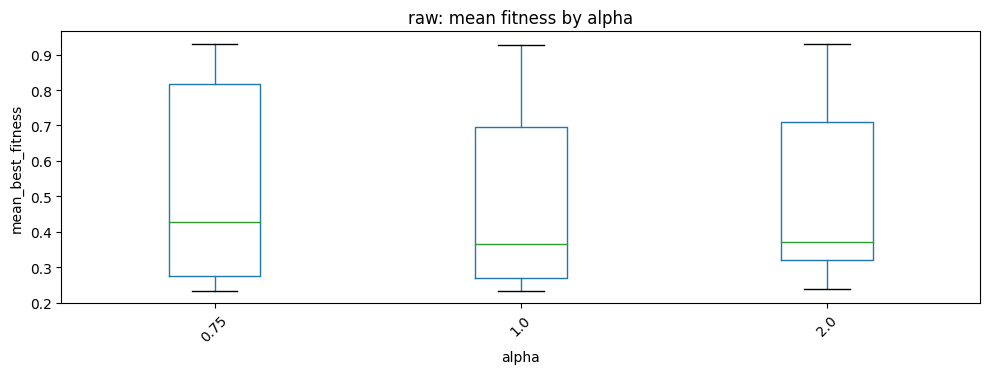

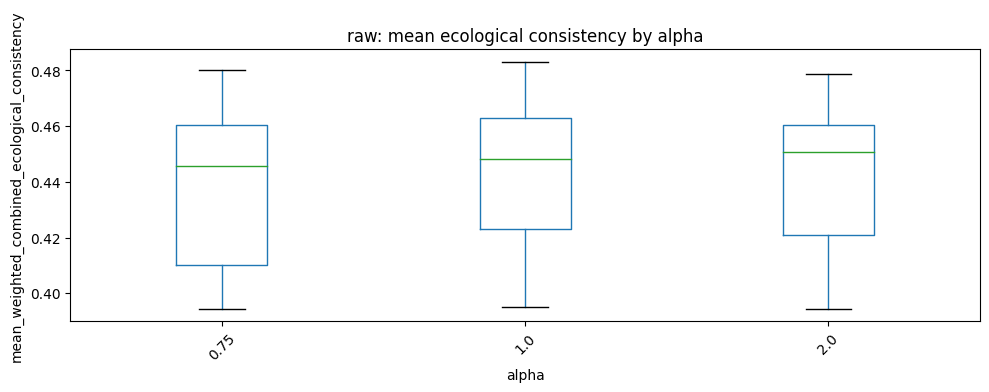

===== beta =====


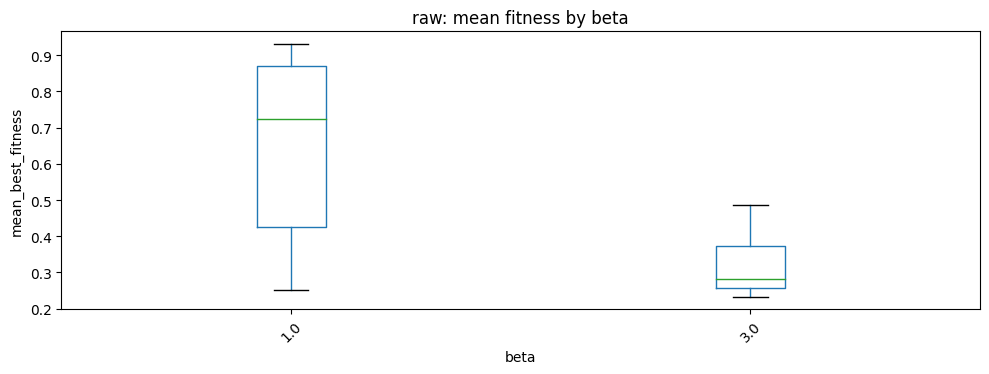

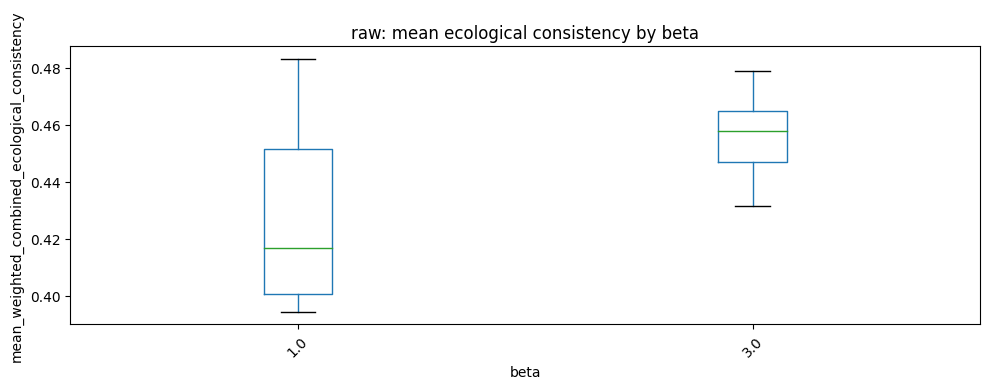

===== evaporation =====


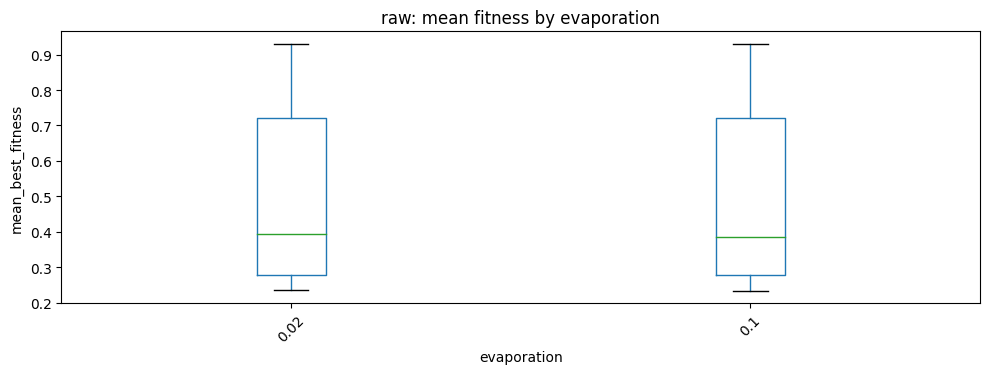

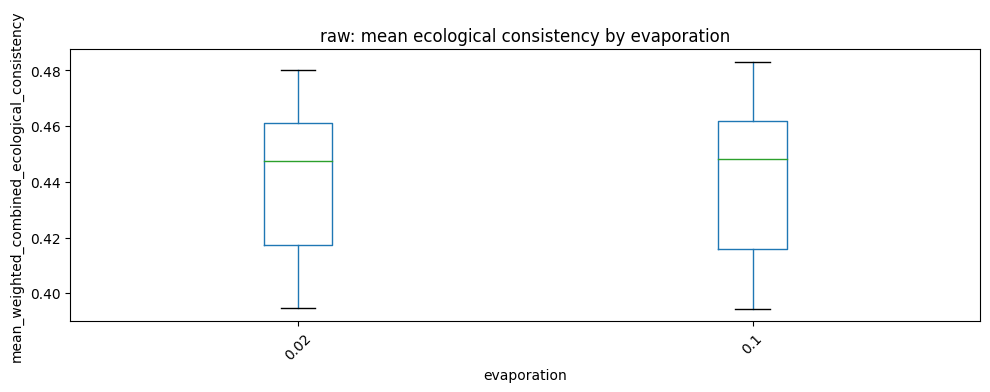

===== q =====


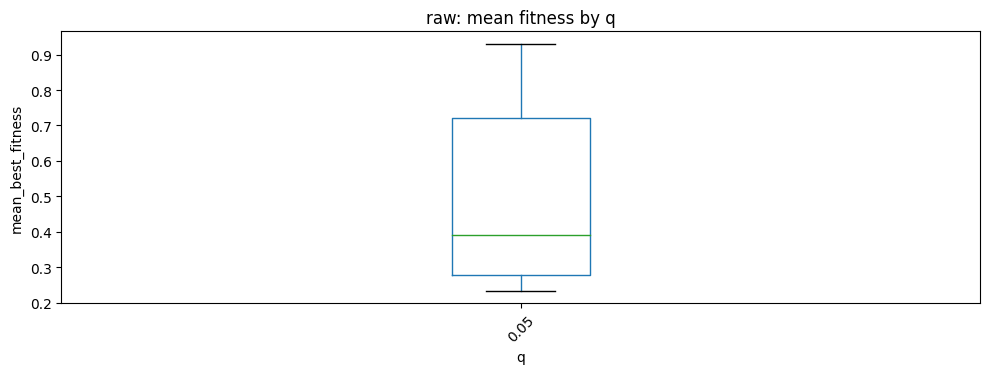

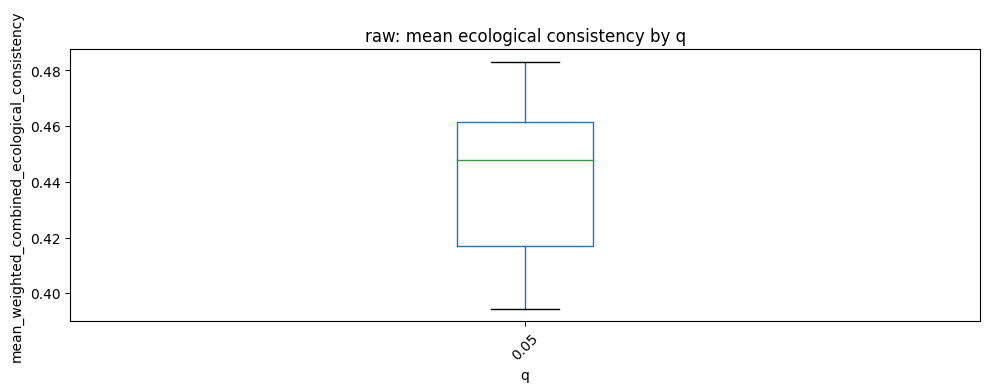

In [19]:
for param in ["pheromone_update", "alpha", "beta", "evaporation", "q"]:
    print(f"===== {param} =====")
    plot_box_by_group(summary, FITNESS_COL, param, f"{FEATURE_MODE}: mean fitness by {param}")
    plot_box_by_group(summary, ECO_COL, param, f"{FEATURE_MODE}: mean ecological consistency by {param}")

## 9. Fitness vs ecology

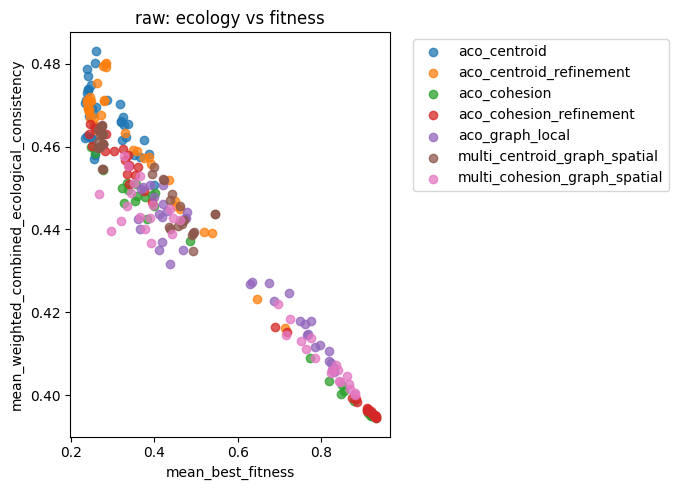

Pearson correlation


,mean_best_fitness,mean_weighted_combined_ecological_consistency,mean_ari_vs_kmeans
mean_best_fitness,1.000000,-0.974222,-0.973840
mean_weighted_combined_ecological_consistency,-0.974222,1.000000,0.985073
mean_ari_vs_kmeans,-0.973840,0.985073,1.000000


Spearman correlation


,mean_best_fitness,mean_weighted_combined_ecological_consistency,mean_ari_vs_kmeans
mean_best_fitness,1.000000,-0.943827,-0.961912
mean_weighted_combined_ecological_consistency,-0.943827,1.000000,0.981831
mean_ari_vs_kmeans,-0.961912,0.981831,1.000000


In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
for algorithm, subset in summary.groupby("algorithm"):
    ax.scatter(subset[FITNESS_COL], subset[ECO_COL], label=algorithm, alpha=0.75)
ax.set_xlabel(FITNESS_COL)
ax.set_ylabel(ECO_COL)
ax.set_title(f"{FEATURE_MODE}: ecology vs fitness")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Pearson correlation")
display(summary[[FITNESS_COL, ECO_COL, ARI_COL]].corr(method="pearson"))
print("Spearman correlation")
display(summary[[FITNESS_COL, ECO_COL, ARI_COL]].corr(method="spearman"))

## 10. Export analysis tables

In [ ]:
OUTPUT_DIR.mkdir(exist_ok=True)

tables = {
    "top5_by_fitness": top_by_fitness,
    "top5_by_ecology": top_by_ecology,
    "overall_config_distribution": overall_config_distribution,
    "overall_run_distribution": overall_run_distribution,
    "algorithm_means": algorithm_means,
    "parameter_means": parameter_means,
    "algorithm_distribution": algorithm_distribution,
    "parameter_distribution": parameter_distribution,
}

for name, table in tables.items():
    table.to_csv(OUTPUT_DIR / f"{FEATURE_MODE}_{name}.csv", index=False)

print("Saved analysis tables to:", OUTPUT_DIR)